In [1]:
print("Installing dependencies...")

!pip install -q timm

import os, json, random
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from sklearn.metrics import *

Installing dependencies...

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CFG = {
    "image_size": 512,
    "patch_size": 32,
    "grid": 16,
    "train_K": 32,
    "patch_resize": 224,
    
    "lr": 3e-3,
    "epochs": 200,
    "batch_size": 32,   # ⚡ larger batch (fast)
    
    "device": "cuda:2" if torch.cuda.is_available() else "cpu",
    "threshold": 0.01,
    
    "cache_dir": "feature_cache",
    "hard_mining_start_epoch": 5,
}

os.makedirs(CFG["cache_dir"], exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
print("Device:", CFG["device"])

Device: cuda:2


In [3]:
from sklearn.model_selection import train_test_split

DATASET_ROOT = "dataset"

def build_manifest(root):
    data = []
    root = Path(root)
    
    for cls in root.iterdir():
        if not cls.is_dir(): continue
        label = 0 if cls.name.lower()=="healthy" else 1
        
        for plant in cls.iterdir():
            if not plant.is_dir(): continue
            
            for img in plant.glob("*.*"):
                if img.suffix.lower() in [".jpg",".jpeg",".png"]:
                    data.append({
                        "image_path": str(img),
                        "disease": label,
                        "plant": plant.name
                    })
    return data

full_data = build_manifest(DATASET_ROOT)

labels = [x["disease"] for x in full_data]

train_data, temp_data = train_test_split(
    full_data, test_size=0.3, stratify=labels, random_state=42
)

temp_labels = [x["disease"] for x in temp_data]

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_labels, random_state=42
)

train_manifest = train_data
val_manifest = val_data
test_manifest = test_data

print(len(train_manifest), len(val_manifest), len(test_manifest))

19038 4080 4080


In [4]:
pos = sum(x["disease"] for x in train_manifest)
neg = len(train_manifest) - pos
pos_weight = torch.tensor(neg/pos).to(CFG["device"])
print("pos_weight:", pos_weight.item())

pos_weight: 1.3157767057418823


In [5]:
backbone = timm.create_model(
    "tf_efficientnetv2_b1",
    pretrained=True,
    num_classes=0
).to(CFG["device"])

backbone.eval()
print("Backbone ready")

Backbone ready


In [6]:
print("Creating FAST feature cache...")

from torchvision.transforms import functional as TF

transform = T.Compose([
    T.Resize((CFG["image_size"], CFG["image_size"])),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

BATCH_SIZE_CACHE = 8   # adjust (4–16 depending on GPU)

def extract_patches_tensor(img_tensor):
    # img_tensor: (3, 512, 512)
    patches = img_tensor.unfold(1, 32, 32).unfold(2, 32, 32)
    # shape → (3,16,16,32,32)
    patches = patches.permute(1,2,0,3,4).contiguous()
    patches = patches.view(-1,3,32,32)   # (256,3,32,32)
    return patches

def process_batch(batch_paths):
    imgs = []
    for p in batch_paths:
        img = Image.open(p).convert("RGB")
        img = transform(img)   # (3,512,512)
        imgs.append(img)
    
    imgs = torch.stack(imgs).to(CFG["device"])  # (B,3,512,512)
    
    all_feats = []
    
    with torch.no_grad():
        for img in imgs:
            patches = extract_patches_tensor(img)   # (256,3,32,32)
            
            # upscale all patches together
            patches = torch.nn.functional.interpolate(
                patches, size=(224,224), mode='bilinear'
            )
            
            feats = []
            for i in range(0,256,64):
                feats.append(backbone(patches[i:i+64]))
            
            feats = torch.cat(feats)
            all_feats.append(feats.cpu())
    
    return all_feats


all_data = train_manifest + val_manifest + test_manifest

paths = [x["image_path"] for x in all_data]

for i in tqdm(range(0, len(paths), BATCH_SIZE_CACHE)):
    
    batch_paths = paths[i:i+BATCH_SIZE_CACHE]
    
    save_paths = [
        os.path.join(CFG["cache_dir"], Path(p).stem + ".pt")
        for p in batch_paths
    ]
    
    # skip if all already exist
    if all(os.path.exists(sp) for sp in save_paths):
        continue
    
    feats_batch = process_batch(batch_paths)
    
    for sp, feats in zip(save_paths, feats_batch):
        torch.save(feats, sp)

print("✅ FAST cache complete!")

Creating FAST feature cache...


100%|████████████████████████████████████| 3400/3400 [00:00<00:00, 13284.91it/s]

✅ FAST cache complete!


In [10]:
def stratified_indices(K=32):
    step = 256 // K
    return [random.randint(i*step, (i+1)*step-1) for i in range(K)]

hard_pool = {}

def update_hard_pool(path, probs):
    hard_pool[path] = np.abs(0.5 - probs)

def get_hard_indices(path, K):
    if path not in hard_pool:
        return None
    return np.argsort(hard_pool[path])[-K:].tolist()

In [11]:
class FeatureDataset(Dataset):
    def __init__(self, manifest, mode="train", epoch=0):
        self.data = manifest
        self.mode = mode
        self.epoch = epoch
    
    def __getitem__(self, idx):
        row = self.data[idx]
        path = row["image_path"]
        label = float(row["disease"])
        
        feat_path = os.path.join(CFG["cache_dir"], Path(path).stem + ".pt")
        feats = torch.load(feat_path)
        
        if self.mode=="train":
            if self.epoch >= CFG["hard_mining_start_epoch"]:
                idxs = get_hard_indices(path, CFG["train_K"]) or stratified_indices()
            else:
                idxs = stratified_indices()
        else:
            idxs = list(range(256))
        
        return feats[idxs], torch.tensor(label), path
    
    def __len__(self):
        return len(self.data)

In [13]:
class MILModel(nn.Module):
    def __init__(self, d=1280):
        super().__init__()
        
        self.patch_cls = nn.Linear(d,1)
        self.V = nn.Linear(d,512)
        self.w = nn.Linear(512,1)
        self.leaf_cls = nn.Linear(d,1)
    
    def forward(self,f):
        z_i = self.patch_cls(f).squeeze(-1)
        a = torch.softmax(self.w(torch.tanh(self.V(f))).squeeze(-1), dim=1)
        F = (a.unsqueeze(-1)*f).sum(1)
        z = self.leaf_cls(F).squeeze(-1)
        return z, z_i, a

In [14]:
model = MILModel().to(CFG["device"])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, CFG["epochs"])

scaler = torch.cuda.amp.GradScaler()

print("Model ready")

Model ready


/tmp/ipykernel_242/1467284440.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [15]:
best_f1=0
patience=10
counter=0

for epoch in range(CFG["epochs"]):
    
    print(f"\nEpoch {epoch+1}")
    
    train_loader = DataLoader(
        FeatureDataset(train_manifest,"train",epoch),
        batch_size=CFG["batch_size"],
        shuffle=True,
        num_workers=0
    )
    
    val_loader = DataLoader(
        FeatureDataset(val_manifest,"val"),
        batch_size=CFG["batch_size"],
        shuffle=False,
        num_workers=0
    )
    
    model.train()
    total_loss=0
    
    for feats,labels,paths in tqdm(train_loader):
        feats = feats.to(CFG["device"])
        labels = labels.to(CFG["device"])
        
        with torch.amp.autocast("cuda"):
            z,z_i,_ = model(feats)
            loss = criterion(z,labels)
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss+=loss.item()
        
        probs = torch.sigmoid(z_i).detach().cpu().numpy()
        for i,p in enumerate(paths):
            update_hard_pool(p, probs[i])
    
    print("Train Loss:", total_loss/len(train_loader))
    
    # VALIDATION
    model.eval()
    preds,targets=[],[]
    
    with torch.no_grad():
        for feats,labels,_ in val_loader:
            feats = feats.to(CFG["device"])
            z,_,_ = model(feats)
            p = torch.sigmoid(z).cpu().numpy()
            
            preds.extend((p>0.5).astype(int))
            targets.extend(labels.numpy())
    
    f1 = f1_score(targets,preds)
    print("Val F1:",f1)
    
    if f1>best_f1:
        best_f1=f1
        counter=0
        torch.save(model.state_dict(),"best_model.pt")
        print("Saved best model")
    else:
        counter+=1
    
    if counter>=patience:
        print("Early stopping")
        break
    
    scheduler.step()


Epoch 1


  0%|                                                   | 0/595 [00:00<?, ?it/s]/tmp/ipykernel_242/1403389776.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = to

Train Loss: 0.6574749805346256
Val F1: 0.2755072877965133
Saved best model

Epoch 2


  0%|                                                   | 0/595 [00:00<?, ?it/s]/tmp/ipykernel_242/1403389776.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = to

Train Loss: 0.6444701980142032
Val F1: 0.3046723804257672
Saved best model

Epoch 3


...

Train Loss: 0.6419149000604614
Val F1: 0.31711317659923455

Epoch 20


  0%|                                                   | 0/595 [00:00<?, ?it/s]/tmp/ipykernel_242/1403389776.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = to

Train Loss: 0.6463577593575005
Val F1: 0.29167874746303274

Epoch 21


  0%|                                                   | 0/595 [00:00<?, ?it/s]/tmp/ipykernel_242/1403389776.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = to

Train Loss: 0.64258871884907
Val F1: 0.280225988700565
Early stopping


In [16]:
from pathlib import Path
from sklearn.model_selection import train_test_split

def build_manifest(root):
    data = []
    root = Path(root)
    
    for cls in root.iterdir():
        if not cls.is_dir(): continue
        label = 0 if cls.name.lower()=="healthy" else 1
        
        for plant in cls.iterdir():
            if not plant.is_dir(): continue
            
            for img in plant.glob("*.*"):
                if img.suffix.lower() in [".jpg",".jpeg",".png"]:
                    data.append({
                        "image_path": str(img),
                        "disease": label,
                        "plant": plant.name
                    })
    return data

full_data = build_manifest("dataset")

labels = [x["disease"] for x in full_data]

train_data, temp_data = train_test_split(
    full_data, test_size=0.3, stratify=labels, random_state=42
)

temp_labels = [x["disease"] for x in temp_data]

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_labels, random_state=42
)

test_manifest = test_data

In [17]:
class FeatureDataset(Dataset):
    def __init__(self, manifest):
        self.data = manifest
    
    def __getitem__(self, idx):
        row = self.data[idx]
        path = row["image_path"]
        label = float(row["disease"])
        
        feat_path = os.path.join(CFG["cache_dir"], Path(path).stem + ".pt")
        feats = torch.load(feat_path)
        
        return feats, torch.tensor(label), path
    
    def __len__(self):
        return len(self.data)

In [18]:
class MILModel(nn.Module):
    def __init__(self, d=1280):
        super().__init__()
        self.patch_cls = nn.Linear(d,1)
        self.V = nn.Linear(d,512)
        self.w = nn.Linear(512,1)
        self.leaf_cls = nn.Linear(d,1)
    
    def forward(self,f):
        z_i = self.patch_cls(f).squeeze(-1)
        a = torch.softmax(self.w(torch.tanh(self.V(f))).squeeze(-1), dim=1)
        F = (a.unsqueeze(-1)*f).sum(1)
        z = self.leaf_cls(F).squeeze(-1)
        return z, z_i, a

model = MILModel().to(CFG["device"])

In [19]:
model.load_state_dict(torch.load("best_model.pt", map_location=CFG["device"]))
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


/tmp/ipykernel_242/3766632170.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location=CFG["device"]))


In [30]:
def infer(image_path):
    feat_path = os.path.join(CFG["cache_dir"], Path(image_path).stem + ".pt")

    feats = torch.load(feat_path).unsqueeze(0).to(CFG["device"])

    with torch.no_grad():
        z, z_i, a = model(feats)

    # Whole-leaf probability
    leaf_prob = torch.sigmoid(z).item()

    # Patch probabilities
    probs = torch.sigmoid(z_i).cpu().numpy()[0]

    # Attention weights
    attn = a.cpu().numpy()[0]

    # ---------------------------------
    # HEALTHY LEAF
    # ---------------------------------
    if leaf_prob < 0.5:
        severity = 0.0
        disease = "Healthy"
        grade = "No Disease"
        present = False

    # ---------------------------------
    # DISEASED LEAF
    # ---------------------------------
    else:
        severity = float((probs * attn).sum() * 100)

        # Clamp
        severity = max(0.0, min(severity, 100.0))

        disease = "FusariumWilt"
        present = True

        if severity < 10:
            grade = "Mild"
        elif severity < 25:
            grade = "Moderate"
        elif severity < 50:
            grade = "Severe"
        else:
            grade = "Critical"

    print("Leaf Probability :", round(leaf_prob, 4))
    print("Disease          :", disease)
    print("Severity         :", round(severity, 2), "%")
    print("Grade            :", grade)
    print("Present          :", present)

    return {
        "leaf_probability": leaf_prob,
        "disease": disease,
        "severity": severity,
        "grade": grade,
        "present": present,
        "patch_probs": probs,
        "attention": attn
    }

In [31]:
def show_heatmap(probs):
    grid = probs.reshape(16,16)

    # normalize 0 to 1
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap="jet")
    plt.colorbar(label="Relative Disease Intensity")
    plt.title("Normalized Disease Heatmap")
    plt.axis("off")
    plt.show()

Running inference on: dataset/fusariumwilt/banana/379_color.jpg
Leaf Probability : 0.5648
Disease          : FusariumWilt
Severity         : 51.28 %
Grade            : Critical
Present          : True


/tmp/ipykernel_242/3241144626.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load(feat_path).unsqueeze(0).to(CFG["device"])


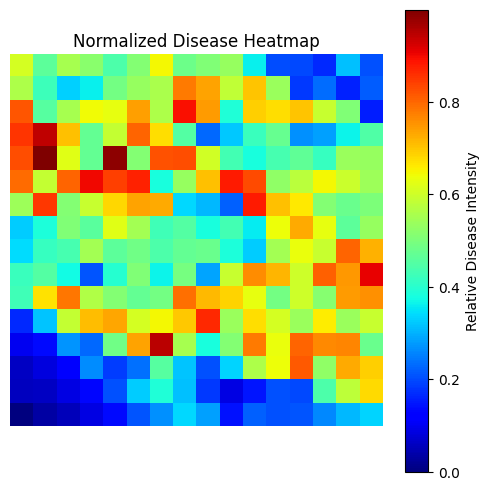

In [32]:
# pick one test image
sample_path = test_manifest[0]["image_path"]

print("Running inference on:", sample_path)

result = infer(sample_path)

show_heatmap(result["patch_probs"])

In [23]:
test_loader = DataLoader(
    FeatureDataset(test_manifest),
    batch_size=1,
    shuffle=False
)

preds, targets = [], []

for feats, labels, _ in test_loader:
    feats = feats.to(CFG["device"])
    
    with torch.no_grad():
        z, _, _ = model(feats)
    
    p = torch.sigmoid(z).cpu().numpy()
    
    preds.append(int(p > 0.5))
    targets.append(int(labels.item()))

print("F1:", f1_score(targets, preds))
print("Accuracy:", accuracy_score(targets, preds))

/tmp/ipykernel_242/2640725359.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load(feat_path)


F1: 0.6817555599291478
Accuracy: 0.6036764705882353


In [24]:
from pathlib import Path
from sklearn.model_selection import train_test_split

def build_manifest(root):
    data = []
    root = Path(root)
    
    for cls in root.iterdir():
        if not cls.is_dir(): continue
        label = 0 if cls.name.lower()=="healthy" else 1
        
        for plant in cls.iterdir():
            if not plant.is_dir(): continue
            
            for img in plant.glob("*.*"):
                if img.suffix.lower() in [".jpg",".jpeg",".png"]:
                    data.append({
                        "image_path": str(img),
                        "disease": label,
                        "plant": plant.name
                    })
    return data

full_data = build_manifest("dataset")

labels = [x["disease"] for x in full_data]

train_data, temp_data = train_test_split(
    full_data, test_size=0.3, stratify=labels, random_state=42
)

temp_labels = [x["disease"] for x in temp_data]

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_labels, random_state=42
)

test_manifest = test_data
print("Test samples:", len(test_manifest))

Test samples: 4080


In [25]:
y_true, y_pred, y_score = [], [], []
severities = []

for feats, labels, paths in tqdm(test_loader):
    feats = feats.to(CFG["device"])
    label = int(labels.item())

    with torch.no_grad():
        z, z_i, a = model(feats)

    # ---------------------------------
    # Classification
    # ---------------------------------
    p_leaf = torch.sigmoid(z).cpu().numpy()[0]
    pred = int(p_leaf > 0.5)

    # ---------------------------------
    # Severity (aligned with current infer pipeline)
    # ---------------------------------
    probs = torch.sigmoid(z_i).cpu().numpy()[0]
    attn = a.cpu().numpy()[0]

    if pred == 0:
        severity = 0.0
    else:
        suspicious_mask = probs > 0.50

        if suspicious_mask.sum() == 0:
            severity = float(probs.mean() * 15)
        else:
            lesion_attention = attn[suspicious_mask].sum()
            lesion_strength = probs[suspicious_mask].mean()

            severity = float(lesion_attention * lesion_strength * 100)

        severity = max(0.0, min(severity, 100.0))

    # ---------------------------------
    # Store results
    # ---------------------------------
    y_true.append(label)
    y_pred.append(pred)
    y_score.append(float(p_leaf))
    severities.append(severity)

  0%|                                                  | 0/4080 [00:00<?, ?it/s]/tmp/ipykernel_242/2640725359.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = to

In [26]:
def show_heatmap(image_path, probs):
    img = plt.imread(image_path)

    heat = probs.reshape(16,16)
    heat = np.kron(heat, np.ones((32,32)))   # Upsample to 512x512

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.imshow(heat, cmap="jet", alpha=0.5)
    plt.colorbar(label="Disease Intensity")
    plt.title("Patch Heatmap Overlay")
    plt.axis("off")
    plt.show()

Mean Severity   : 28.28
Median Severity : 33.51


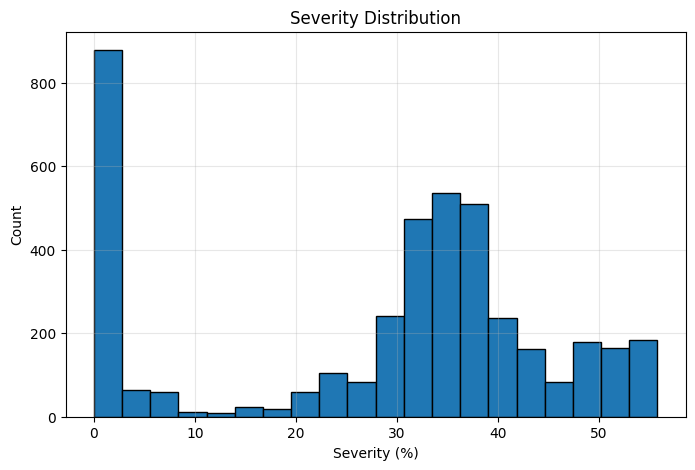

In [27]:
print("Mean Severity   :", round(np.mean(severities), 2))
print("Median Severity :", round(np.median(severities), 2))

plt.figure(figsize=(8,5))
plt.hist(severities, bins=20, edgecolor="black")
plt.title("Severity Distribution")
plt.xlabel("Severity (%)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()


🔹 Classification Metrics
Accuracy     : 0.6037
Precision    : 0.5217
Recall       : 0.9835
F1-score ⭐  : 0.6818
ROC-AUC      : 0.4823

🔹 Confusion Matrix
[[ 731 1588]
 [  29 1732]]

TN: 731 | FP: 1588
FN: 29 | TP: 1732

🔹 Severity Metrics
Mean Severity   : 28.28
Median Severity : 33.51
Std Deviation   : 17.38
Min Severity    : 0.00
Max Severity    : 55.80

🔹 Severity Breakdown
Healthy Mean Severity  : 23.09
Diseased Mean Severity : 35.12
Diseased Median        : 35.43


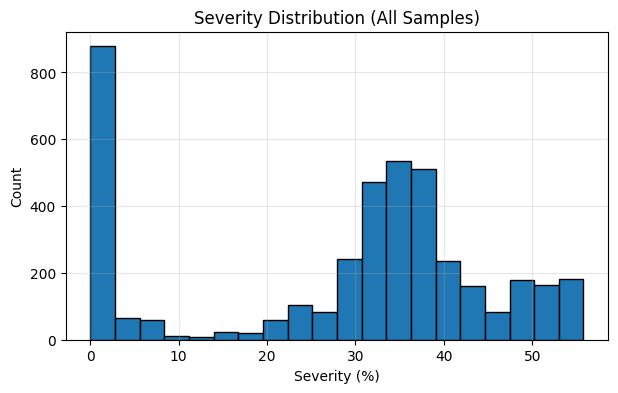

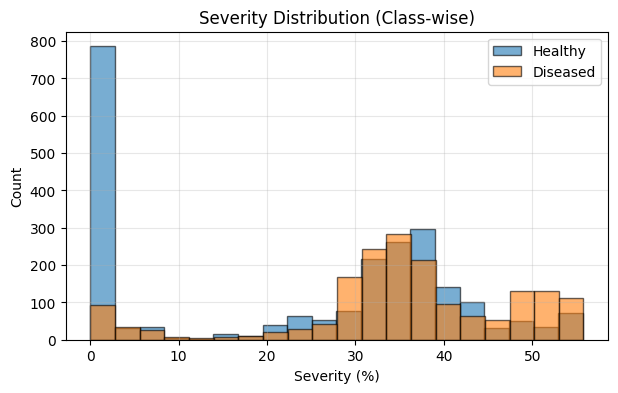

In [28]:
# ===== CLASSIFICATION METRICS =====

print("\n🔹 Classification Metrics")

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_true, y_score)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score ⭐  : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")


# ===== CONFUSION MATRIX =====

print("\n🔹 Confusion Matrix")

cm = confusion_matrix(y_true, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")


# ===== SEVERITY METRICS =====

print("\n🔹 Severity Metrics")

severities_np = np.array(severities)

print(f"Mean Severity   : {severities_np.mean():.2f}")
print(f"Median Severity : {np.median(severities_np):.2f}")
print(f"Std Deviation   : {severities_np.std():.2f}")
print(f"Min Severity    : {severities_np.min():.2f}")
print(f"Max Severity    : {severities_np.max():.2f}")


# ===== HEALTHY vs DISEASED =====

print("\n🔹 Severity Breakdown")

y_true_np = np.array(y_true)

healthy_sev  = severities_np[y_true_np == 0]
diseased_sev = severities_np[y_true_np == 1]

if len(healthy_sev) > 0:
    print(f"Healthy Mean Severity  : {healthy_sev.mean():.2f}")

if len(diseased_sev) > 0:
    print(f"Diseased Mean Severity : {diseased_sev.mean():.2f}")
    print(f"Diseased Median        : {np.median(diseased_sev):.2f}")


# ===== HISTOGRAM (ALL) =====

plt.figure(figsize=(7,4))
plt.hist(severities_np, bins=20, edgecolor="black")
plt.title("Severity Distribution (All Samples)")
plt.xlabel("Severity (%)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()


# ===== CLASS-WISE HISTOGRAM =====

plt.figure(figsize=(7,4))

if len(healthy_sev) > 0:
    plt.hist(healthy_sev, bins=20, alpha=0.6, label="Healthy", edgecolor="black")

if len(diseased_sev) > 0:
    plt.hist(diseased_sev, bins=20, alpha=0.6, label="Diseased", edgecolor="black")

plt.legend()
plt.title("Severity Distribution (Class-wise)")
plt.xlabel("Severity (%)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()